In [1]:
import json
from plot_centroid import plot_centroid
from pathlib import Path
import pandas as pd

In [2]:
import os
print(os.getcwd())

/app/river/results_drift


In [3]:

DATASET = "Synthetic_airplanes"


BASE_DIR = Path("/app/river")

path = BASE_DIR / "transformer" /"config_dataset.json"

with open(path, "r", encoding="utf-8-sig") as f:
    config = json.load(f)
# with open("transformer/config_dataset.json", "r", encoding="utf-8-sig") as f:
#     config = json.load(f)

districts_settings = config[DATASET]["DISTRICTS_SETTINGS"]

df_pred  = pd.read_csv(f"{DATASET}_predictions.csv")
df_drift = pd.read_csv(f"{DATASET}_drift_log.csv")



In [4]:
# df_drift[df_drift["event_type"]=="centroid"]
df_pred.tail(5)

,n_seen,timestamp,district,y,y_hat
1159555,1159555,2008-03-02 13:00:00,South,9.0,-0.419449
1159556,1159556,2008-03-02 13:00:00,Global,28.0,23.340793
1159557,1159557,2008-03-02 13:00:00,South,23.0,2.600289
1159558,1159558,2008-03-02 13:00:00,South,-14.0,-0.198369
1159559,1159559,2008-03-02 13:00:00,Northeast,-19.0,10.813881


In [5]:
print(df_drift[df_drift['event_type']=='centroid'].head(20) )
df_drift.dtypes

                timestamp  n_seen event_type   district
1147  2008-02-07 00:00:00   14531   centroid  Northeast
1148  2008-02-10 00:00:00  169613   centroid      South
1149  2008-02-15 00:00:00   54810   centroid    Midwest
1150  2008-02-17 00:00:00   18050   centroid  Northeast
1151  2008-02-21 00:00:00   61888   centroid    Midwest
1152  2008-02-24 00:00:00  228226   centroid      South
1153  2008-02-26 00:00:00   21295   centroid  Northeast


timestamp     object
n_seen         int64
event_type    object
district      object
dtype: object

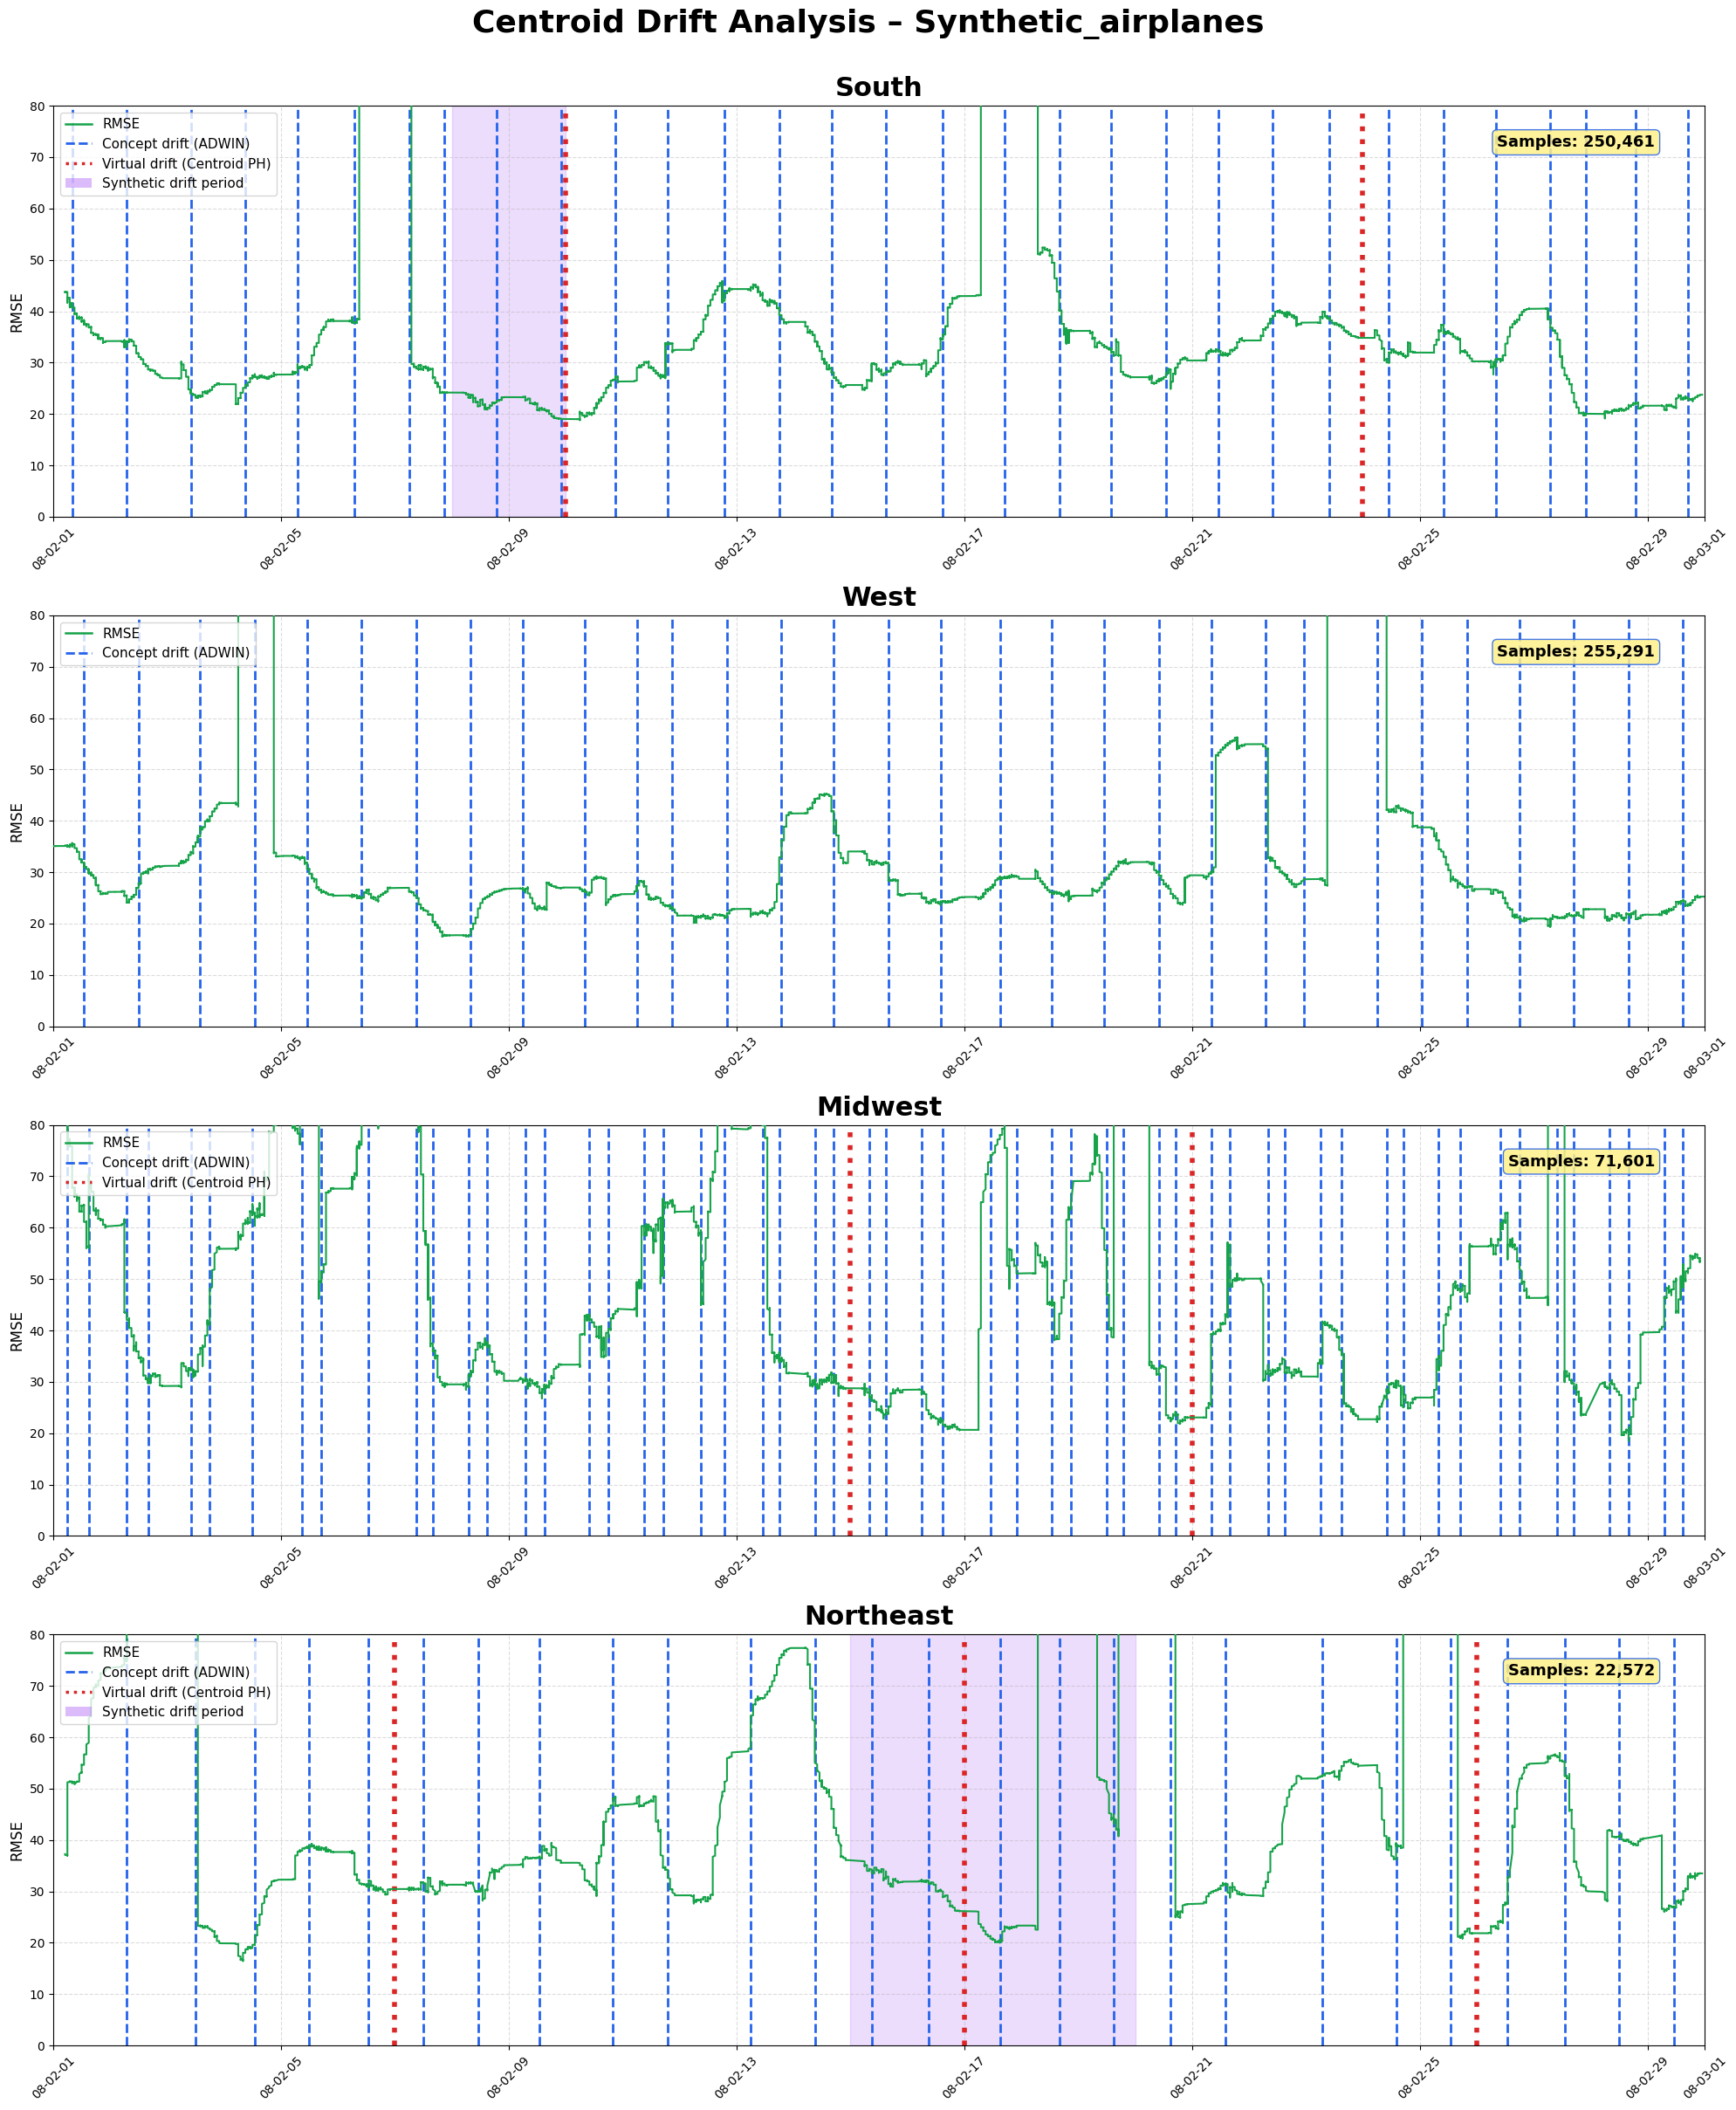

In [6]:
plot_centroid(
        df_predictions=df_pred,
        df_drift=df_drift,
        districts_settings=districts_settings,
        dataset=DATASET,
        date_from="2008-02-01",   
        date_to="2008-03-01",           
        save_path=f"plot_drift_{DATASET}.png",
    )